In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
import bagpipes as pipes
from bagpipes import model_galaxy 
os.chdir("/Users/christine/FA26_1501")

model_components = {}
model_components["redshift"] = 0 # Observed redshift (mandatory)
model_components["veldisp"] = 300 # Max age of birth clouds: Gyr
model_components["t_bc"] = 0.01


# Dict containing SFH info
dblplaw = {}
dblplaw["tau"] = 12
dblplaw["alpha"] = 30
dblplaw["beta"] = 0.5
dblplaw["metallicity"] = 0.8
dblplaw["massformed"] = 11
model_components["dblplaw"] = dblplaw

dust = {}
dust["type"] = "Calzetti" #attenuation law
dust["Av"] = 0.2
dust["eta"] = 3
model_components["dust"] = dust

nebular = {}
nebular["logU"] = -3
model_components["nebular"] = nebular

wavelength_grid = np.arange(2000, 7005, 5) # units A

uvista_filt_list = ["filters/CFHT_MegaCam.u.dat",
                    "filters/CFHT_MegaCam.g.dat",
                    "filters/CFHT_MegaCam.r.dat",
                    "filters/CFHT_MegaCam.i.dat",
                    "filters/CFHT_MegaCam.z.dat",
                    "filters/Subaru_Suprime.z.dat",
                    "filters/Paranal_VISTA.Y.dat",
                    "filters/Paranal_VISTA.J.dat",
                    "filters/Paranal_VISTA.H.dat",
                    "filters/Paranal_VISTA.Ks.dat",
                    "filters/Spitzer_IRAC.I1.dat",
                    "filters/Spitzer_IRAC.I2.dat"]


In [5]:
import copy
new = copy.deepcopy(model_components)


Text(0, 0.5, '$L_\\lambda\\ /\\ 10^{40}$ erg s$^{-1}$ \\AA$^{-1}$')

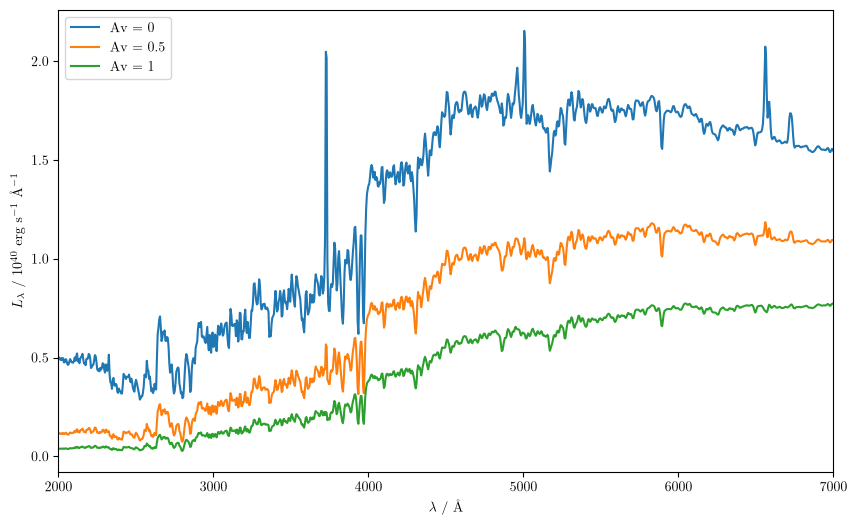

In [9]:
Dust_val = [0, 0.5, 1]
fig, ax = plt.subplots(figsize = (10, 6))
for av in Dust_val:
    new = copy.deepcopy(model_components)
    new['dust']['Av'] = av
    model = model_galaxy(new, filt_list=None, spec_wavs=wavelength_grid, spec_units='ergscma', phot_units='ergscma', index_list=None)
    wavelength = model.spectrum[:, 0]
    luminosity = model.spectrum[:, 1]
    ax.plot(wavelength, luminosity / 10**40, label = f"Av = {av}")
ax.legend()
ax.set_xlim(np.min(wavelength), np.max(wavelength))
ax.set_xlabel(r"$\lambda$ / \AA")
ax.set_ylabel(r"$L_\lambda\ /\ 10^{40}$ erg s$^{-1}$ \AA$^{-1}$")


## Experiment 1: How varying the V-band attenuation (Av) changes the galaxy's SED profile?

By increasing Av from 0 to 0.5 and 1, respectively, we can see that at 2000A the light is dimmed by a factor of 10. In comparison, at the far right end of the spectrum, the 7000A light is only dimmed by a factor of 3. 